In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df=pd.read_csv("loan_data.csv")

In [61]:
df.shape

(45000, 14)

In [62]:
df.sample(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
18640,33.0,male,Bachelor,30551.0,10,MORTGAGE,6600.0,PERSONAL,12.99,0.22,6.0,659,Yes,0
40161,46.0,male,High School,1080952.0,27,MORTGAGE,28389.0,PERSONAL,12.75,0.03,15.0,639,Yes,0
3229,24.0,female,Bachelor,43804.0,0,OWN,6500.0,EDUCATION,5.42,0.15,2.0,581,Yes,0
184,25.0,male,Bachelor,241005.0,4,RENT,18000.0,EDUCATION,16.32,0.07,3.0,708,Yes,0
28347,35.0,female,High School,24927.0,16,RENT,5500.0,MEDICAL,12.69,0.22,9.0,675,No,0


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [64]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

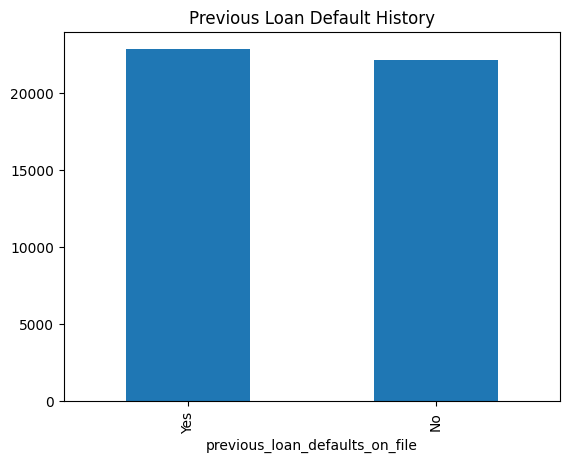

In [65]:
df["previous_loan_defaults_on_file"].value_counts().plot(kind="bar")
plt.title("Previous Loan Default History")
plt.show()

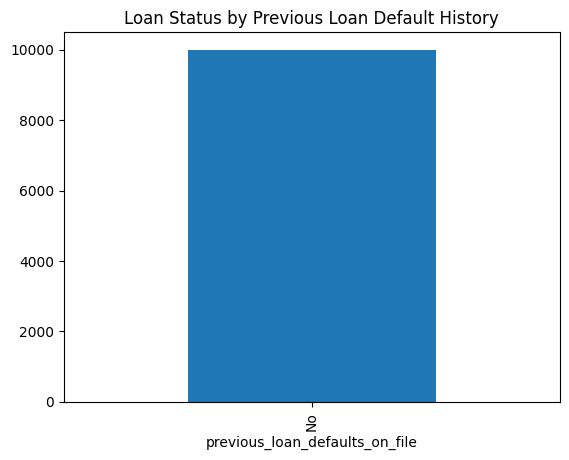

In [66]:
df[df["loan_status"] == 1]["previous_loan_defaults_on_file"].value_counts().plot(kind="bar")
plt.title("Loan Status by Previous Loan Default History")
plt.show()

In [67]:
df["previous_loan_defaults_on_file"]=df["previous_loan_defaults_on_file"].replace({
    "Yes":1,
    "No":0
})

In [68]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,0,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,0,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,0,1


In [69]:
pd.crosstab(df["person_gender"],df["loan_status"])

loan_status,0,1
person_gender,,
female,15674,4485
male,19326,5515


<Axes: xlabel='loan_status', ylabel='person_gender'>

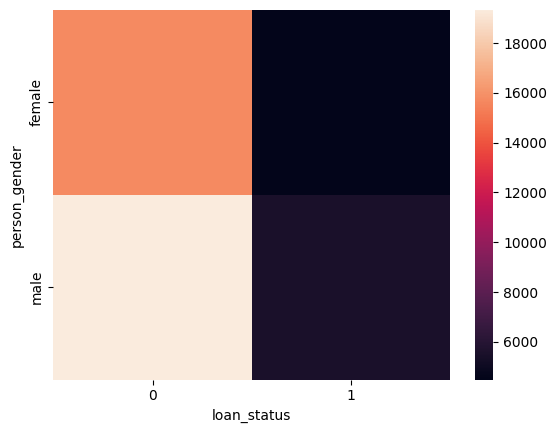

In [70]:
sns.heatmap(pd.crosstab(df["person_gender"],df["loan_status"]))

<Axes: >

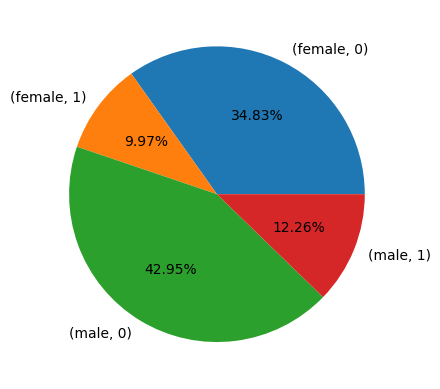

In [71]:
df.groupby("person_gender")["loan_status"].value_counts().plot(kind="pie",autopct="%.2f%%")

In [72]:
df.groupby("person_gender")["loan_status"].sum()

person_gender
female    4485
male      5515
Name: loan_status, dtype: int64

<Axes: >

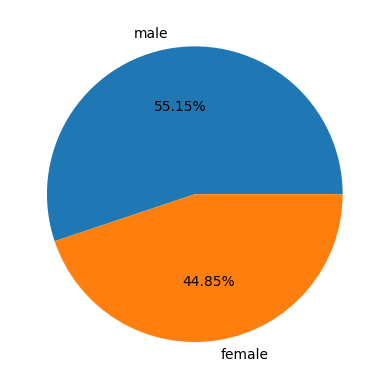

In [73]:
df[df["loan_status"]==1]["person_gender"].value_counts().plot(kind="pie", autopct="%.2f%%")

In [74]:
apv_amt=df[df["loan_status"]==1].groupby("loan_intent")["loan_amnt"].sum()
print("Total Approved Loan Amount :",apv_amt)

Total Approved Loan Amount : loan_intent
DEBTCONSOLIDATION    23864853.0
EDUCATION            17044874.0
HOMEIMPROVEMENT      12435452.0
MEDICAL              26360100.0
PERSONAL             16085453.0
VENTURE              12766166.0
Name: loan_amnt, dtype: float64


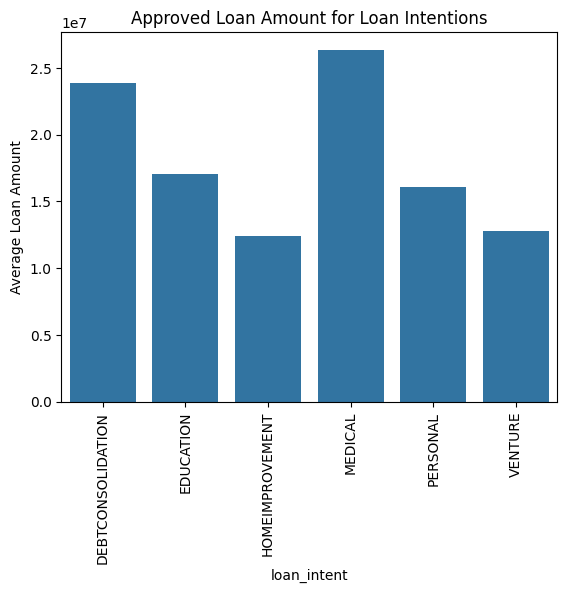

In [75]:
sns.barplot(x=apv_amt.index, y=apv_amt.values)
plt.xticks(rotation=90)
plt.ylabel("Average Loan Amount")
plt.title("Approved Loan Amount for Loan Intentions")
plt.show()

<Axes: xlabel='loan_amnt', ylabel='person_income'>

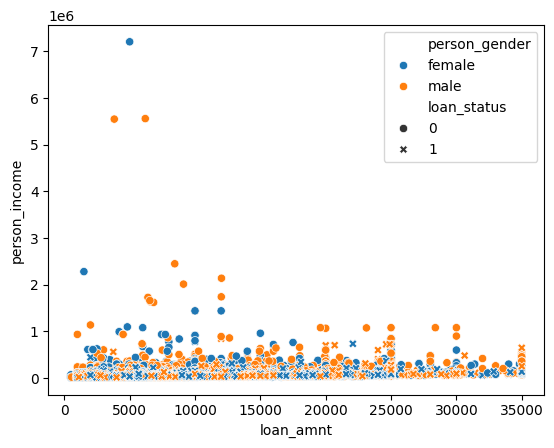

In [76]:
sns.scatterplot(y=df["person_income"],x=df["loan_amnt"],hue=df["person_gender"],style=df["loan_status"])

(array([3.7447e+04, 6.6560e+03, 7.7700e+02, 9.8000e+01, 1.3000e+01,
        2.0000e+00, 0.0000e+00, 2.0000e+00, 2.0000e+00, 3.0000e+00]),
 array([ 20. ,  32.4,  44.8,  57.2,  69.6,  82. ,  94.4, 106.8, 119.2,
        131.6, 144. ]),
 <BarContainer object of 10 artists>)

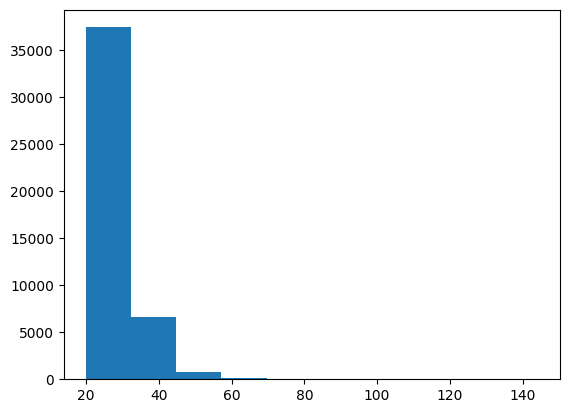

In [77]:
plt.hist(df["person_age"])

In [78]:
df["credit_score"].describe()

count    45000.000000
mean       632.608756
std         50.435865
min        390.000000
25%        601.000000
50%        640.000000
75%        670.000000
max        850.000000
Name: credit_score, dtype: float64

In [79]:
min_cre=df[df["loan_status"]==1]["credit_score"].min()
print("The lowest credit score with loan approval:",min_cre)

The lowest credit score with loan approval: 431


In [80]:
max_cre=df[df["loan_status"]==0]["credit_score"].max()
print("The largest credit score with loan rejection:",max_cre)

The largest credit score with loan rejection: 850


In [81]:
approved=df[df['loan_status']==1]
approved.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,0,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,0,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,0,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,0,1


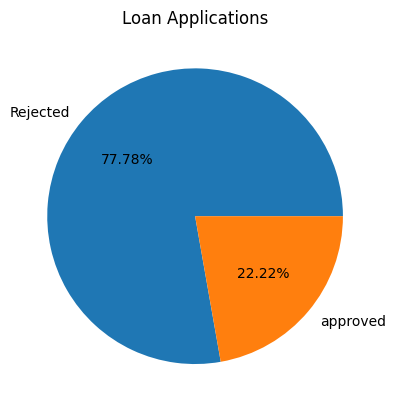

In [92]:
plt.pie(df["loan_status"].value_counts(),autopct="%.2f%%",labels=["Rejected","approved"])
plt.title("Loan Applications")
plt.show()

In [93]:
amt_given=df["loan_amnt"].sum()
interest=(df["loan_amnt"]*df["loan_int_rate"]*0.01).sum()
amt_collected=amt_given+interest

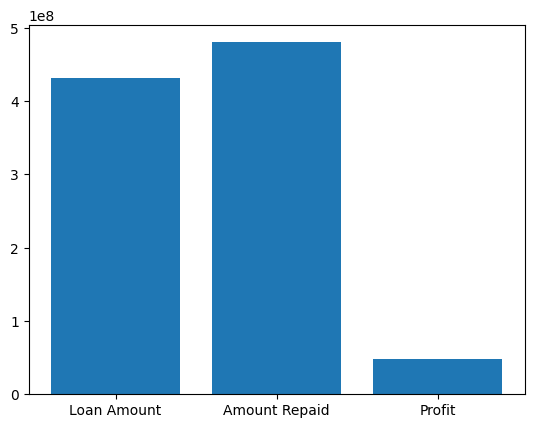

In [94]:
plt.bar(["Loan Amount","Amount Repaid", "Profit"],[amt_given,amt_collected,amt_collected-amt_given])
plt.show()

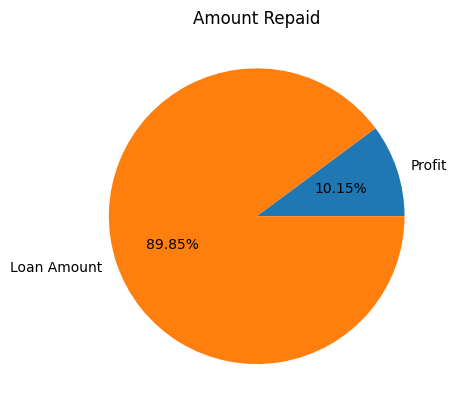

In [95]:
plt.pie([amt_collected-amt_given,amt_given],labels=["Profit","Loan Amount"],autopct="%.2f%%")
plt.title("Amount Repaid")
plt.show()